# Rentabilidade da próxima campanha de marketing

**Autor:** Matheus Picotti · **Como rodar:** [abrir no Google Colab](https://colab.research.google.com/github/picotti-matheus/rentabilidade-campanha/blob/main/analise_campanha.ipynb) → `Ambiente de execução → Executar tudo` (a base é lida do GitHub, sem upload). O código de cada célula fica recolhido; clique em "Mostrar código" para ver.

---

## Resumo em 1 minuto

**O problema.** Cada contato custa **3 MU** e cada venda rende **11 MU**, então só vale contatar quem tem **mais de 27,3%** de chance de comprar. O piloto contatou 2.240 clientes aleatórios, converteu 14,9% e perdeu **3.046 MU**. O problema não foi a campanha, e sim **em quem ela foi gasta**.

**O que a análise mostra**
1. **9% dos registros são cópias**, o que distorce o resultado do piloto em 372 MU. Sem as cópias, a base tem 2.039 clientes únicos.
2. **Quem compra:** o sinal mais forte é ter aceitado campanhas anteriores (9% de conversão para quem nunca aceitou, contra 32% para quem aceitou uma e até 82% para 3 ou mais). Depois vêm quem comprou recentemente (30% contra 6%), clientes de maior valor, quem compra por catálogo e clientes mais antigos.
3. **Segmentação:** 3 perfis (Econômico 41%, Intermediário 29%, Premium 30%) orientam mensagem e canal, mas **nenhum dá lucro se contatado inteiro** (o melhor converte 25%). Algumas faixas isoladas passam raspando do break-even (28% a 34%); só o histórico de campanhas passa com folga.
4. **Um score de propensão** (regressão logística) contata **18% da base**, converte **59%** e capta **69% dos compradores**.
5. **A decisão é robusta:** a curva de lucro é plana perto do ótimo e, mesmo se só metade dos 11 MU for margem, o modelo continua lucrando, enquanto a regra simples passa a dar prejuízo.

| Estratégia | % da base contatada | Conversão | Lucro simulado na base deduplicada (2.039 clientes) | Lucro por 1.000 clientes | Lucro por 100 mil clientes |
|---|---|---|---|---|---|
| Contatar todos (como no piloto) | 100% | 15% | −2.674 *(−3.046 com as cópias, como no enunciado)* | **−1.311** | −131 mil |
| Regra simples: só quem já aceitou campanha | 21% | 41% | +653 | +320 | +32 mil |
| **Score de propensão (recomendado)** | **18%** | **59%** | **+1.278** | **+627** | **+63 mil** |

*Resultados em MU, medidos fora da amostra (o modelo nunca é avaliado em clientes que viu no treino). "Por 1.000 clientes" se refere a clientes da base, não a contatos.*

**Recomendação.** (1) Deduplicar a base de contatos. (2) Calcular o score de toda a base no dia do disparo e contatar quem tiver mais de 27,3%. (3) Adaptar a mensagem ao perfil do cliente. (4) Testar com grupo de controle e uma amostra de exploração abaixo do corte, para medir o efeito real da campanha e manter o modelo aprendendo.

---

### Como o notebook está organizado

| Seção | Item do enunciado |
|---|---|
| **0. Preparação:** economia da campanha, tratamento dos dados, variáveis | base para tudo |
| **1. Análise dos dados e insights** | item 1 |
| **2. Segmentação de clientes** | item 2 |
| **3. Estratégia e recomendação** | item 3 |
| **4. Limitações e próximos passos** | item 4 |
| **Apêndice:** glossário, dicionário de dados, detalhes do tratamento e testes de robustez | consulta |

In [1]:
# @title Configuração e carga dos dados { display-mode: "form" }
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Formatação no padrão brasileiro
def br(x, dec=0):
    return f"{x:,.{dec}f}".replace(",", "X").replace(".", ",").replace("X", ".")
def pct(x, dec=0):
    return br(100 * x, dec) + "%"
def mu(x):
    return ("+" if x > 0.5 else "−" if x < -0.5 else "") + br(abs(x))
def formata(tabela, spec):
    out = tabela.copy().astype(object)
    for col, f in spec.items():
        out[col] = ["—" if isinstance(v, float) and np.isnan(v) else f(v) for v in tabela[col]]
    return out

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: br(x, 2))

# Identidade visual: uma cor de destaque (onde agir) + cinza (contexto)
ACCENT, GRAY, INK, MUTED = "#EA1D2C", "#B5B3AD", "#1F1F1F", "#6B6A66"
SEG_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]  # paleta categórica validada (3 primeiros slots)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRAY, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titleweight": "bold", "axes.titlesize": 11, "axes.titlelocation": "left",
    "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True, "grid.color": "#ECEBE8", "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "legend.frameon": False,
})

DATA_URL = "https://raw.githubusercontent.com/picotti-matheus/rentabilidade-campanha/main/data/base_campanha.csv"

def load_data():
    # 1) arquivo local (rodando na pasta do projeto); 2) GitHub (Colab ou qualquer máquina)
    local = Path("data/base_campanha.csv")
    return pd.read_csv(local if local.exists() else DATA_URL)

raw = load_data()
import sklearn
print(f"Base carregada: {br(raw.shape[0])} linhas × {raw.shape[1]} colunas | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")

Base carregada: 2.240 linhas × 29 colunas | pandas 3.0.6 | scikit-learn 1.9.1


---
# 0. Preparação

## 0.1 Economia da campanha

O dicionário descreve `Z_CostContact` e `Z_Revenue` só como "campo disponibilizado". As duas colunas têm **o mesmo valor para todos os clientes** (3 e 11) e reconciliam exatamente com o P&L do enunciado:

- 2.240 contatos × **3** = 6.720 de custo, ou seja, `Z_CostContact` é o **custo por contato**;
- 334 compradores × **11** = 3.674 de receita, ou seja, `Z_Revenue` é a **receita por conversão**.

Isso define a regra de decisão de toda a análise:

$$\text{lucro esperado de contatar um cliente} = 11 \cdot p - 3 > 0 \iff p > \frac{3}{11} \approx 27{,}3\%$$

**Só vale contatar quem tem mais de 27,3% de chance de comprar.** O piloto converteu 14,9%.

In [2]:
# @title Reconciliação com o P&L do enunciado { display-mode: "form" }
COST = raw["Z_CostContact"].unique().item()
REVENUE = raw["Z_Revenue"].unique().item()
BREAKEVEN = COST / REVENUE

def pnl(y):
    # P&L de contatar todos os clientes do vetor y (1 = comprou)
    y = np.asarray(y)
    return pd.Series({"clientes": len(y), "conversões": y.sum(), "conversão": y.mean(),
                      "custo": len(y) * COST, "receita": y.sum() * REVENUE,
                      "lucro": y.sum() * REVENUE - len(y) * COST})

piloto = pnl(raw["Response"])
enunciado = pd.Series({"clientes": 2240, "custo": 6720, "receita": 3674, "lucro": -3046})
print(f"Custo por contato: {COST} | Receita por conversão: {REVENUE} | Break-even: {pct(BREAKEVEN, 1)}")
pd.DataFrame({"calculado da base": piloto[enunciado.index], "enunciado": enunciado}).astype(int)

Custo por contato: 3 | Receita por conversão: 11 | Break-even: 27,3%


,calculado da base,enunciado
clientes,2240,2240
custo,6720,6720
receita,3674,3674
lucro,-3046,-3046


## 0.2 Qualidade e tratamento dos dados

In [3]:
# @title Diagnóstico de qualidade { display-mode: "form" }
feature_cols = [c for c in raw.columns if c not in ("ID", "Response")]
dup_mask = raw.duplicated(subset=feature_cols, keep=False)
dup_groups = raw[dup_mask].groupby(feature_cols, dropna=False)["Response"].nunique()

pd.DataFrame([
    ("Registros duplicados: IDs diferentes, demais campos idênticos", len(raw) - raw.drop_duplicates(subset=feature_cols).shape[0]),
    ("  ↳ grupos de cópias com respostas diferentes ao piloto", (dup_groups > 1).sum()),
    ("Renda nula", raw["Income"].isna().sum()),
    ("Renda = 666.666 (valor impossível)", (raw["Income"] == 666666).sum()),
    ("Ano de nascimento < 1901", (raw["Year_Birth"] < 1901).sum()),
    ("Estado civil inválido (Alone/Absurd/YOLO)", raw["Marital_Status"].isin(["Alone", "Absurd", "YOLO"]).sum()),
    ("Colunas constantes (Z_CostContact, Z_Revenue)", 2),
], columns=["problema", "qtd"]).set_index("problema")

,qtd
problema,
"Registros duplicados: IDs diferentes, demais campos idênticos",201
↳ grupos de cópias com respostas diferentes ao piloto,19
Renda nula,24
Renda = 666.666 (valor impossível),1
Ano de nascimento < 1901,3
Estado civil inválido (Alone/Absurd/YOLO),7
"Colunas constantes (Z_CostContact, Z_Revenue)",2


| Problema | Decisão | Por quê |
|---|---|---|
| **201 registros duplicados (9%)** | Deduplicar: uma linha por cliente | Ver abaixo. |
| Renda nula (24) e 666.666 (1) | Mediana, com uma flag marcando o caso | A próxima campanha também terá clientes sem renda, então remover só esconderia o problema. A mediana não é puxada por extremos. Detalhes no Apêndice A.3. |
| Nascimento antes de 1901 (3) | Mediana | Erro de digitação (cliente com mais de 114 anos). |
| Estado civil `Alone`, `Absurd`, `YOLO` (7) | `Single` | `Alone` é solteiro; os outros dois são lixo de cadastro (A.3). |
| `2n Cycle` | Igual a `Master` | Nomenclatura europeia para mestrado. |
| `Z_CostContact`, `Z_Revenue` | Usados como parâmetros do P&L | São constantes. |

**Registros duplicados.** São 201 linhas com ID diferente, mas **todos os outros ~25 campos idênticos**, inclusive recência, gasto em cada categoria e compras em cada canal. Duas contas reais da mesma pessoa *dividiriam* o histórico, e não o *repetiriam*. O mais provável é **registro copiado no processo de dados**. Exemplo:

In [4]:
# @title Exemplo de registro duplicado { display-mode: "form" }
exemplo_cols = ["ID", "Year_Birth", "Education", "Marital_Status", "Income", "Kidhome", "Teenhome",
                "Dt_Customer", "Recency", "MntWines", "MntMeatProducts", "NumStorePurchases", "Response"]
raw[raw["ID"].isin([4491, 873, 2968, 8800])].sort_values("Income")[exemplo_cols]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntMeatProducts,NumStorePurchases,Response
39,2968,1943,PhD,Divorced,"48.948,00",0,0,2013-02-01,53,437,206,5,1
894,8800,1943,PhD,Divorced,"48.948,00",0,0,2013-02-01,53,437,206,5,1
1060,4491,1949,Master,Married,"62.845,00",1,1,2012-10-01,3,1099,45,10,0
1342,873,1949,Master,Married,"62.845,00",1,1,2012-10-01,3,1099,45,10,1


**Decisão:** deduplicar. Com as cópias, o mesmo cliente seria contado duas vezes nas taxas e, na validação do modelo, apareceria no treino e no teste ao mesmo tempo (como fazer a prova com o gabarito). Nos 19 grupos em que as cópias têm respostas diferentes, o cliente conta como comprador se alguma cópia comprou; a alternativa está testada no Apêndice A.6. **Daqui em diante, a análise usa a base limpa e compara as estratégias por 1.000 clientes.**

In [5]:
# @title Deduplicação e efeito no resultado do piloto { display-mode: "form" }
dedup = (raw.groupby(feature_cols, dropna=False, sort=False)
            .agg(ID=("ID", "min"), Response=("Response", "max"), n_cadastros=("ID", "size"),
                 resposta_conflitante=("Response", "nunique"))
            .reset_index())
dedup["resposta_conflitante"] = dedup["resposta_conflitante"] > 1

piloto_limpo = pnl(dedup["Response"])
comparacao = pd.DataFrame({"como reportado (2.240 linhas)": piloto, "base limpa (2.039 clientes)": piloto_limpo}).T
comparacao["lucro por 1.000 clientes"] = comparacao["lucro"] / comparacao["clientes"] * 1000
formata(comparacao[["clientes", "conversões", "custo", "receita", "lucro", "lucro por 1.000 clientes"]],
        {"clientes": br, "conversões": br, "custo": br, "receita": br, "lucro": mu, "lucro por 1.000 clientes": mu})

,clientes,conversões,custo,receita,lucro,lucro por 1.000 clientes
como reportado (2.240 linhas),2.240,334,6.720,3.674,−3.046,−1.360
base limpa (2.039 clientes),2.039,313,6.117,3.443,−2.674,−1.311


**Insight: as cópias distorcem o resultado do piloto em 372 MU (~12% do prejuízo).** Elas somam 201 contatos (603 MU de custo) e 21 compras a mais (231 MU de receita). Seja contato repetido, seja erro de registro, a primeira recomendação é **deduplicar a base de contatos e o reporte de resultado**. Por 1.000 clientes, o diagnóstico praticamente não muda (−1.360 contra −1.311): o problema central continua sendo **em quem a campanha foi gasta**.

In [6]:
# @title Tratamento de renda, idade e estado civil { display-mode: "form" }
df = dedup.copy()

df.loc[df["Income"] > 200_000, "Income"] = np.nan
df["Income_raw"] = df["Income"]  # sem imputação: o modelo imputa dentro da validação (seção 3)
df["income_imputed"] = df["Income"].isna().astype(int)
df["Income"] = df["Income"].fillna(df["Income"].median())

df.loc[df["Year_Birth"] < 1901, "Year_Birth"] = np.nan
df["Year_Birth"] = df["Year_Birth"].fillna(df["Year_Birth"].median())

df["Marital_Status"] = df["Marital_Status"].replace({"Alone": "Single", "Absurd": "Single", "YOLO": "Single"})
df["Education"] = df["Education"].replace({"2n Cycle": "Master"})

print(f"Base tratada: {br(len(df))} clientes únicos | conversão {pct(df['Response'].mean(), 1)} | renda imputada em {df['income_imputed'].sum()} clientes")

Base tratada: 2.039 clientes únicos | conversão 15,4% | renda imputada em 25 clientes


## 0.3 Variáveis derivadas

A base traz o comportamento "picado" em várias colunas (6 de gasto, 3 de compras por canal, 5 de campanhas). As variáveis derivadas **resumem essas colunas em conceitos de negócio**. Uso participações (%) além dos valores absolutos porque quem compra muito tem números altos em *tudo*: a participação separa **como** o cliente compra de **quanto** ele compra.

| Pergunta | Variável | Como é calculada |
|---|---|---|
| Quanto vale e quando comprou? (**RFM**) | `Recency`, `total_purchases`, `total_spend`, `avg_ticket` | Recência (já na base); web + catálogo + loja; soma dos 6 gastos; gasto ÷ compras |
| Como compra? | `web_share`, `catalog_share`, `store_share`, `deal_share` | Compras no canal ÷ total; compras com desconto ÷ total (máx. 100%) |
| O que compra? | `wine_share`, `meat_share` | Gasto na categoria ÷ gasto total. Vinho e carne são 78% do gasto (Apêndice A.4) |
| Quem é? | `age`, `kids`, `has_partner`, `edu_level`, `tenure_days` | 2014 − nascimento; crianças + adolescentes; casado(a) ou junto(a); 0 = Basic … 3 = PhD; dias desde o cadastro |
| Responde a campanha? | `prev_accepted` | Soma das 5 campanhas anteriores aceitas (0 a 5) |

In [7]:
# @title Criação das variáveis derivadas { display-mode: "form" }
REF_DATE = pd.to_datetime(df["Dt_Customer"]).max()
mnt_cols = [c for c in df.columns if c.startswith("Mnt")]
channel_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
cmp_cols = [f"AcceptedCmp{i}" for i in range(1, 6)]

df["age"] = REF_DATE.year - df["Year_Birth"]
df["tenure_days"] = (REF_DATE - pd.to_datetime(df["Dt_Customer"])).dt.days
df["kids"] = df["Kidhome"] + df["Teenhome"]
df["has_partner"] = df["Marital_Status"].isin(["Married", "Together"]).astype(int)
df["edu_level"] = df["Education"].map({"Basic": 0, "Graduation": 1, "Master": 2, "PhD": 3})

df["total_spend"] = df[mnt_cols].sum(axis=1)
df["total_purchases"] = df[channel_cols].sum(axis=1)
df["avg_ticket"] = (df["total_spend"] / df["total_purchases"].replace(0, np.nan)).fillna(0)
for c, name in zip(channel_cols, ["web_share", "catalog_share", "store_share"]):
    df[name] = (df[c] / df["total_purchases"].replace(0, np.nan)).fillna(0)
df["deal_share"] = (df["NumDealsPurchases"] / df["total_purchases"].replace(0, np.nan)).fillna(0).clip(upper=1)
df["wine_share"] = df["MntWines"] / df["total_spend"]
df["meat_share"] = df["MntMeatProducts"] / df["total_spend"]
df["prev_accepted"] = df[cmp_cols].sum(axis=1)
print("Variáveis derivadas criadas.")

Variáveis derivadas criadas.


---
# 1. Análise dos dados e insights: quem converte?

Para cada variável, os clientes são divididos em faixas, e o gráfico mostra a % que comprou no piloto. A linha tracejada é o **break-even de 27,3%**: em uma faixa **vermelha**, contatar todos os clientes dela dá lucro. Por exemplo, quem comprou há 0–19 dias converte 30% e gera 11 × 0,30 − 3 = **+0,30 MU por contato**.

- **Quintis** (gasto, renda, tempo de casa) dividem os clientes em 5 grupos do mesmo tamanho: Q1 são os 20% menores, Q5 os 20% maiores. As faixas de valores estão na tabela abaixo do gráfico.
- **No catálogo**, 26% dos clientes têm zero compras e 22% têm uma, então quintis sairiam desiguais. Por isso uso **nunca (0) / ocasional (1–2) / regular (3–5) / frequente (6+)**.

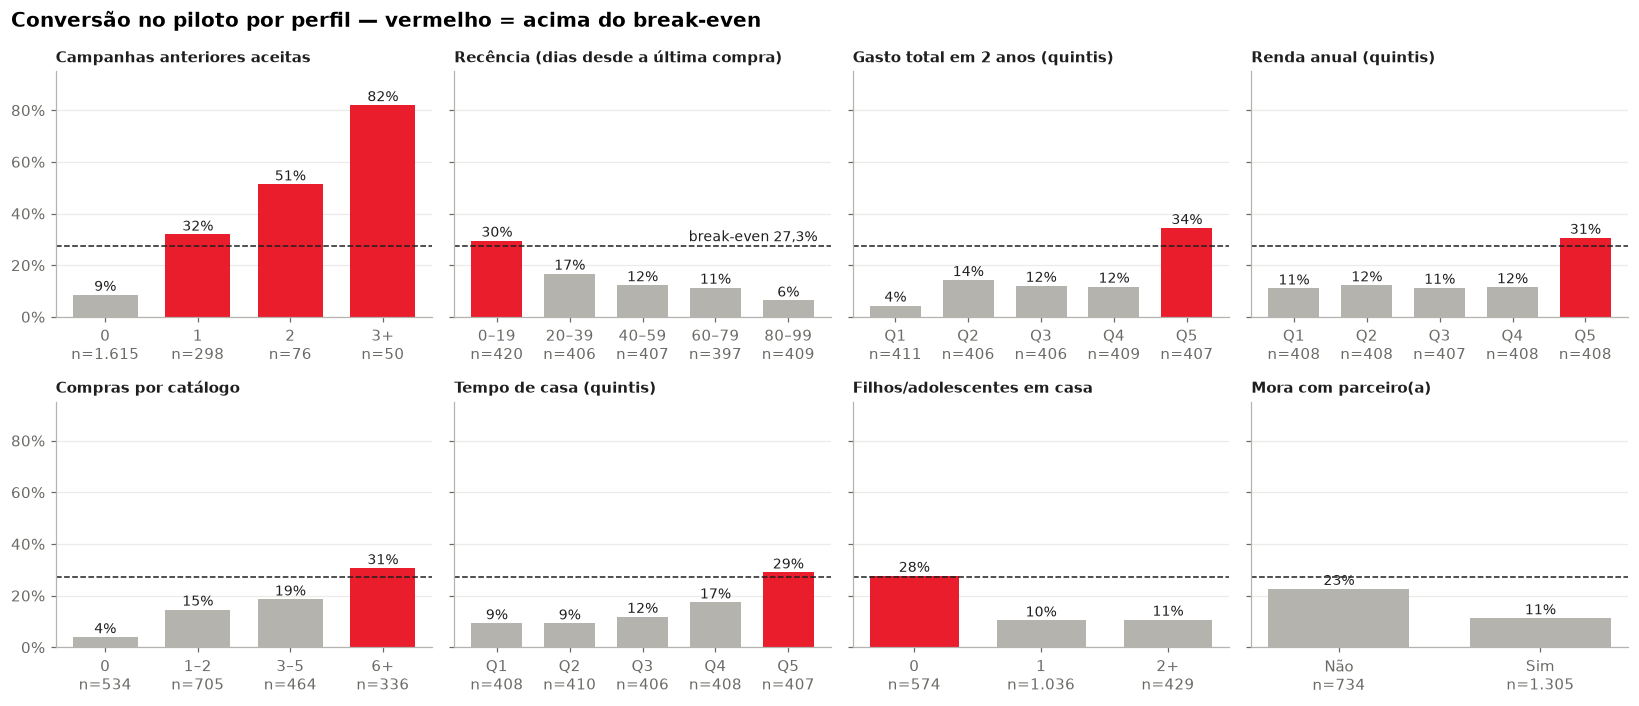

,Gasto total (2 anos),Renda anual,Tempo de casa (dias)
Q1,5 – 55,1.730 – 32.309,0 – 141
Q2,55 – 199,32.309 – 45.086,141 – 282
Q3,199 – 636,45.086 – 58.074,282 – 421
Q4,636 – 1.173,58.074 – 71.678,421 – 560
Q5,1.173 – 2.525,71.678 – 162.397,560 – 699


In [8]:
# @title Conversão por faixa de cada variável { display-mode: "form" }
def conv_by(series, bins=None, labels=None):
    s = pd.qcut(series, bins, duplicates="drop") if isinstance(bins, int) else (pd.cut(series, bins, labels=labels) if bins is not None else series)
    return df.groupby(s, observed=True)["Response"].agg(["mean", "size"])

panels = [
    ("Campanhas anteriores aceitas", conv_by(df["prev_accepted"], [-1, 0, 1, 2, 5], ["0", "1", "2", "3+"])),
    ("Recência (dias desde a última compra)", conv_by(df["Recency"], [-1, 19, 39, 59, 79, 99], ["0–19", "20–39", "40–59", "60–79", "80–99"])),
    ("Gasto total em 2 anos (quintis)", conv_by(df["total_spend"], 5)),
    ("Renda anual (quintis)", conv_by(df["Income"], 5)),
    ("Compras por catálogo", conv_by(df["NumCatalogPurchases"], [-1, 0, 2, 5, 30], ["0", "1–2", "3–5", "6+"])),
    ("Tempo de casa (quintis)", conv_by(df["tenure_days"], 5)),
    ("Filhos/adolescentes em casa", conv_by(df["kids"], [-1, 0, 1, 3], ["0", "1", "2+"])),
    ("Mora com parceiro(a)", conv_by(df["has_partner"].map({0: "Não", 1: "Sim"}))),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharey=True)
for ax, (title, t) in zip(axes.flat, panels):
    labels = [(("Q" + str(i + 1)) if isinstance(idx, pd.Interval) else str(idx)) + f"\nn={br(n)}"
              for i, (idx, n) in enumerate(zip(t.index, t["size"]))]
    colors = [ACCENT if v > BREAKEVEN else GRAY for v in t["mean"]]
    bars = ax.bar(labels, t["mean"], color=colors, width=0.7)
    ax.axhline(BREAKEVEN, color=INK, ls="--", lw=1)
    for b, v in zip(bars, t["mean"]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.015, pct(v), ha="center", fontsize=9, color=INK)
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
    ax.set_ylim(0, 0.95)
axes[0, 1].text(4.4, BREAKEVEN + 0.02, "break-even 27,3%", ha="right", fontsize=9, color=INK)
fig.suptitle("Conversão no piloto por perfil — vermelho = acima do break-even", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
plt.show()

def faixas(col):
    q = pd.qcut(df[col], 5)
    return [f"{br(i.left if k else df[col].min())} – {br(i.right)}" for k, i in enumerate(q.cat.categories)]

pd.DataFrame({"Gasto total (2 anos)": faixas("total_spend"), "Renda anual": faixas("Income"),
              "Tempo de casa (dias)": faixas("tenure_days")}, index=["Q1", "Q2", "Q3", "Q4", "Q5"])

**Principais insights**

1. **Engajamento passado é o sinal mais forte.** Quem nunca aceitou campanha (79% da base) converte **9%**. Quem aceitou 1 converte **32%**; 2, **51%**; 3 ou mais, **82%** (só 50 clientes).
2. **Recência importa muito.** Quem comprou nos últimos 20 dias converte **30%**, 5× mais do que quem está há 80+ dias sem comprar (6%). *Premissa:* a recência foi medida antes do piloto e precisa ser recalculada no dia do disparo.
3. **Valor e canal andam juntos.** Os 20% que mais gastam, os 20% de maior renda e quem compra muito por catálogo convertem ~30%. O catálogo é uma oferta ativa: quem compra por ele já tem o hábito de responder a ofertas.
4. **Clientes mais antigos convertem mais:** 29% no quintil de maior tempo de casa, contra 9% nos mais novos.
5. **Domicílios sem filhos e sem parceiro(a) convertem mais**, provavelmente por renda disponível e decisão individual.
6. **O que não discrimina:** reclamação (só 1% da base, e converte igual aos demais).

Várias faixas passam do break-even, mas **raspando** (28% a 34%); só o engajamento passado passa **com folga** (32% a 82%). E esses sinais se sobrepõem: quem gasta muito também tende a comprar por catálogo e a ter aceitado campanhas. Isso motiva **combinar sinais**: primeiro numa segmentação, depois num modelo.

---
# 2. Segmentação de clientes

Duas camadas, com papéis diferentes:

1. **Perfis (quem é o cliente):** agrupamento K-means sobre perfil e comportamento de compra. Serve para decidir **oferta, mensagem e canal**.
2. **Matriz de ação (quem contatar):** engajamento com campanhas × recência. Serve para decidir **quem contatar** de forma simples, e é a linha de base que o modelo da seção 3 precisa superar.

## 2.1 Perfis

**Como foram construídos**
- **8 variáveis:** renda, gasto total, nº de compras, filhos, % de compras com desconto, visitas ao site, compras por catálogo e % do gasto em vinho.
- **Ficou de fora, de propósito, a resposta às campanhas.** Se entrasse, os grupos seriam "quem compra" contra "quem não compra" e não ensinariam nada sobre o cliente.
- O gasto entra em log (é muito concentrado) e tudo é **padronizado**, para que nenhuma variável pese mais só por causa da escala.
- Testei de 2 a 6 grupos. Com 2 grupos a separação matemática (*silhouette*) é melhor, mas os grupos só dizem "gasta muito" ou "gasta pouco". **Com 3 grupos**, a separação cai de 0,38 para 0,28, ainda aceitável, e cada grupo ganha leitura de negócio.

In [9]:
# @title Agrupamento K-means e perfil de cada persona { display-mode: "form" }
seg_features = ["Income", "total_spend", "total_purchases", "kids", "deal_share",
                "NumWebVisitsMonth", "NumCatalogPurchases", "wine_share"]
X_seg = df[seg_features].copy()
X_seg["total_spend"] = np.log1p(X_seg["total_spend"])
Z = StandardScaler().fit_transform(X_seg)

scores = {k: silhouette_score(Z, KMeans(k, n_init=20, random_state=42).fit_predict(Z)) for k in range(2, 7)}

km = KMeans(3, n_init=20, random_state=42).fit(Z)
df["cluster"] = km.labels_
order = df.groupby("cluster")["total_spend"].median().sort_values().index  # nomes estáveis entre execuções
df["persona"] = pd.Categorical(df["cluster"].map(dict(zip(order, ["Econômico", "Intermediário", "Premium"]))),
                               ["Econômico", "Intermediário", "Premium"], ordered=True)

def profile(g):
    return pd.Series({
        "clientes": br(len(g)), "% da base": pct(len(g) / len(df)),
        "idade (média)": br(g["age"].mean()), "tempo de casa (dias, média)": br(g["tenure_days"].mean()),
        "renda mediana": br(g["Income"].median()), "gasto mediano em 2 anos (MU)": br(g["total_spend"].median()),
        "nº de compras (mediana)": br(g["total_purchases"].median()), "filhos (média)": br(g["kids"].mean(), 1),
        "% compras com desconto": pct(g["deal_share"].mean()), "compras por catálogo (média)": br(g["NumCatalogPurchases"].mean(), 1),
        "% das compras por catálogo": pct(g["catalog_share"].mean()), "% das compras em loja": pct(g["store_share"].mean()),
        "visitas ao site/mês": br(g["NumWebVisitsMonth"].mean(), 1), "% do gasto em vinho": pct(g["wine_share"].mean()),
        "já aceitou campanha antes": pct((g["prev_accepted"] > 0).mean()),
        "conversão no piloto": pct(g["Response"].mean()),
        "lucro se contatar todos (MU)": mu(g["Response"].sum() * REVENUE - len(g) * COST),
    })

print("Silhouette por nº de grupos: " + " | ".join(f"k={k}: {br(v, 2)}" for k, v in scores.items()))
df.groupby("persona", observed=True).apply(profile).T

Silhouette por nº de grupos: k=2: 0,38 | k=3: 0,28 | k=4: 0,26 | k=5: 0,23 | k=6: 0,21


persona,Econômico,Intermediário,Premium
clientes,827,593,619
% da base,41%,29%,30%
idade (média),42,48,46
"tempo de casa (dias, média)",330,382,352
renda mediana,33.168,55.686,74.293
gasto mediano em 2 anos (MU),57,521,1.237
nº de compras (mediana),5,15,20
filhos (média),"1,3","1,2","0,3"
% compras com desconto,37%,24%,7%
compras por catálogo (média),"0,4","2,4","5,9"


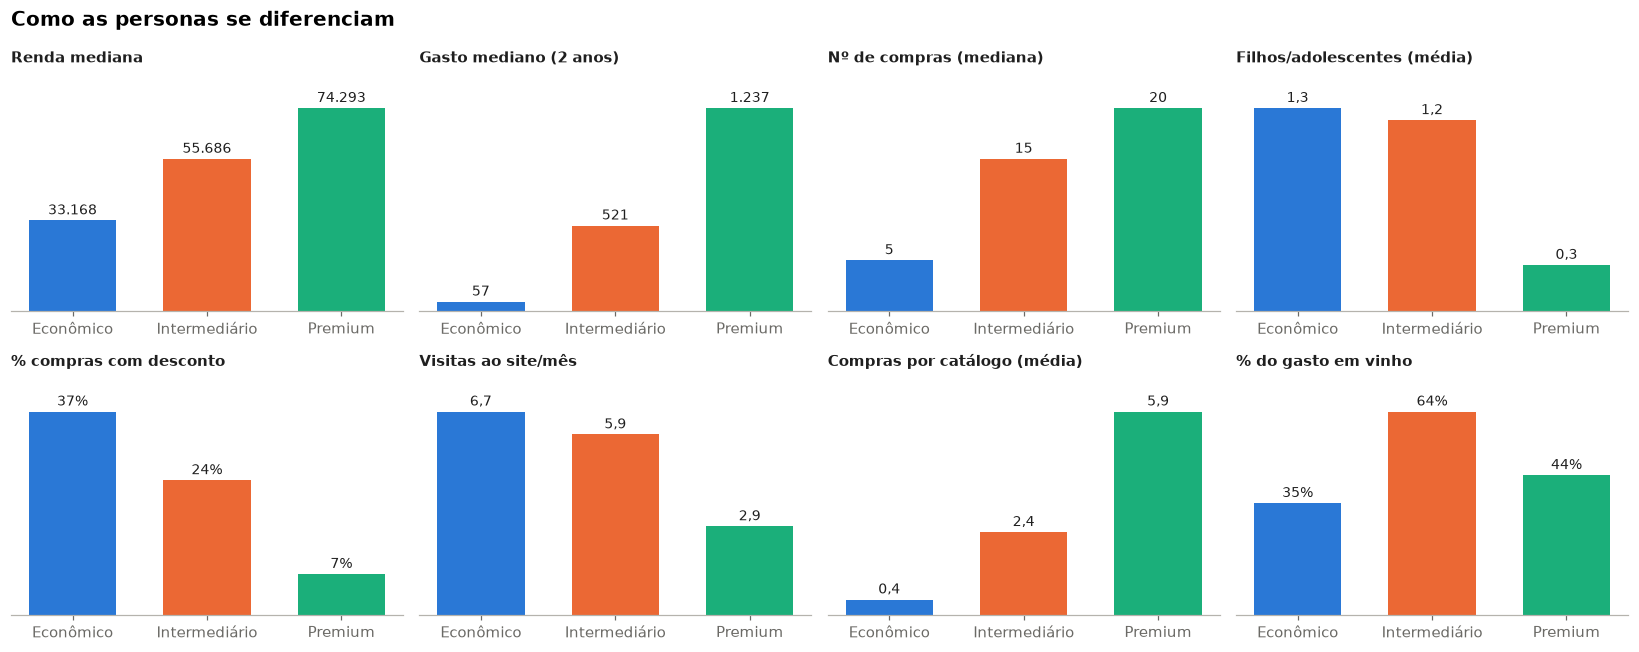

In [10]:
# @title Gráfico: como as personas se diferenciam { display-mode: "form" }
perfil_vars = [
    ("Renda mediana", lambda g: g["Income"].median(), lambda v: br(v)),
    ("Gasto mediano (2 anos)", lambda g: g["total_spend"].median(), lambda v: br(v)),
    ("Nº de compras (mediana)", lambda g: g["total_purchases"].median(), lambda v: br(v)),
    ("Filhos/adolescentes (média)", lambda g: g["kids"].mean(), lambda v: br(v, 1)),
    ("% compras com desconto", lambda g: g["deal_share"].mean(), pct),
    ("Visitas ao site/mês", lambda g: g["NumWebVisitsMonth"].mean(), lambda v: br(v, 1)),
    ("Compras por catálogo (média)", lambda g: g["NumCatalogPurchases"].mean(), lambda v: br(v, 1)),
    ("% do gasto em vinho", lambda g: g["wine_share"].mean(), pct),
]
grouped = df.groupby("persona", observed=True)
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, (title, fn, fmt) in zip(axes.flat, perfil_vars):
    vals = grouped.apply(fn)
    bars = ax.bar(vals.index.astype(str), vals.values, color=SEG_COLORS, width=0.65)
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x() + b.get_width() / 2, v + vals.max() * 0.03, fmt(v), ha="center", fontsize=9, color=INK)
    ax.set_title(title, fontsize=10)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.set_ylim(0, vals.max() * 1.18)
fig.suptitle("Como as personas se diferenciam", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
plt.show()

| Persona | Quem é | Implicação |
|---|---|---|
| **Econômico** (41%) | Renda ~33 mil, gasta pouco, mais jovem, tem filhos; 37% das compras com desconto; visita muito o site, mas compra mais em loja | Sensível a preço: oferta com desconto, canal digital. Converte 11%: **não paga o contato** em massa. |
| **Intermediário** (29%) | Renda ~56 mil, família com filhos, mais velho e com mais tempo de casa; vinho é 64% do gasto | Oferta ligada a vinho/harmonização. Converte 11%: também **não paga** o contato em massa. |
| **Premium** (30%) | Renda ~74 mil, gasta ~22× o Econômico, quase sem filhos; 30% das compras por catálogo; quase não usa desconto | Responde à oferta ativa sem precisar de desconto. É a melhor persona (25%), **mas ainda fica abaixo do break-even** se contatada inteira. |

**Leitura:** nenhuma persona, sozinha, justifica contatar todo mundo. Os perfis são, em boa parte, **faixas de valor**: 82% dos clientes cairiam no mesmo grupo com um simples corte por gasto. Eles também são **robustos**: incluindo o % de carne, 95% dos clientes ficam no mesmo grupo (ambos os testes no Apêndice A.5). O que o agrupamento acrescenta são as dimensões de **domicílio, canal e desconto**. Por isso os perfis servem para **comunicar**, não para decidir quem contatar.

## 2.2 Matriz de ação: engajamento × recência

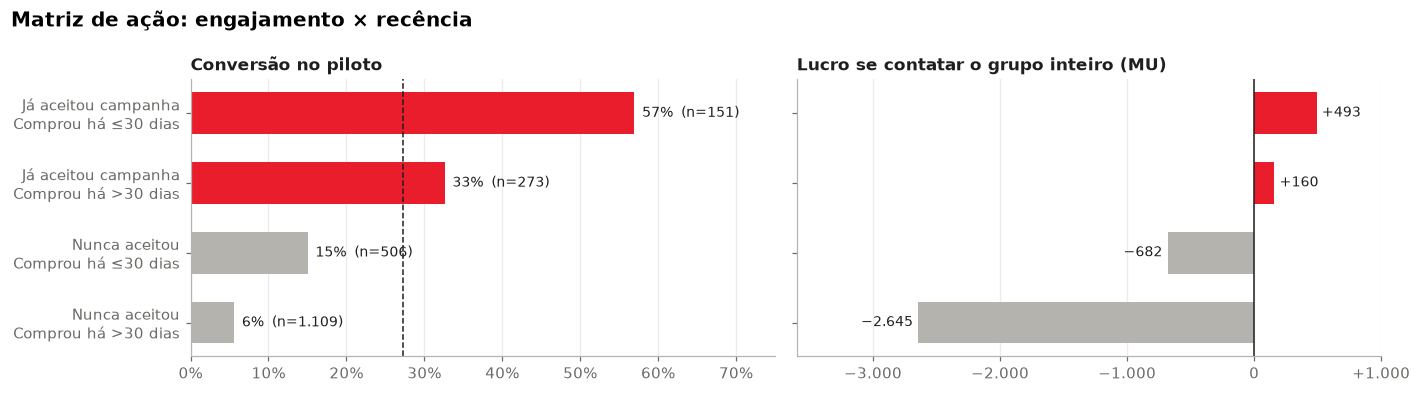

In [11]:
# @title Matriz de ação: conversão e lucro por célula { display-mode: "form" }
df["engajamento"] = np.where(df["prev_accepted"] > 0, "Já aceitou campanha", "Nunca aceitou")
df["recencia"] = np.where(df["Recency"] <= 30, "Comprou há ≤30 dias", "Comprou há >30 dias")

matriz = df.groupby(["engajamento", "recencia"]).apply(
    lambda g: pd.Series({"clientes": len(g), "conversão": g["Response"].mean(),
                         "lucro": g["Response"].sum() * REVENUE - len(g) * COST}))

m = matriz.reset_index()
m["label"] = m["engajamento"] + "\n" + m["recencia"]
m = m.sort_values("conversão")
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
colors = [ACCENT if v > BREAKEVEN else GRAY for v in m["conversão"]]
axes[0].barh(m["label"], m["conversão"], color=colors, height=0.6)
axes[0].axvline(BREAKEVEN, color=INK, ls="--", lw=1)
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
axes[0].set_title("Conversão no piloto")
axes[0].grid(axis="x"); axes[0].grid(axis="y", visible=False)
for i, (v, nn) in enumerate(zip(m["conversão"], m["clientes"])):
    axes[0].text(v + 0.01, i, f"{pct(v)}  (n={br(nn)})", va="center", fontsize=9, color=INK)
axes[0].set_xlim(0, 0.75)
axes[1].barh(m["label"], m["lucro"], color=colors, height=0.6)
axes[1].axvline(0, color=INK, lw=1)
axes[1].set_title("Lucro se contatar o grupo inteiro (MU)")
axes[1].set_yticklabels([]); axes[1].grid(axis="x"); axes[1].grid(axis="y", visible=False)
for i, v in enumerate(m["lucro"]):
    axes[1].text(v + (40 if v >= 0 else -40), i, mu(v), va="center", ha="left" if v >= 0 else "right", fontsize=9, color=INK)
axes[1].set_xlim(-3600, 1000)
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: mu(v)))
fig.suptitle("Matriz de ação: engajamento × recência", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
plt.show()

**Leitura da matriz**

- Nesta matriz, só **quem já aceitou alguma campanha** (21% da base) passa do break-even, e com folga quando também comprou recentemente (**57%** de conversão).
- A recência sozinha passava do break-even na seção 1 (30% para 0–19 dias) porque mistura engajados: entre quem **nunca** aceitou campanha, ter comprado há ≤30 dias leva a só **15%**.
- Os 79% que nunca aceitaram campanha geram −3.327 MU, **mais do que o prejuízo total** (−2.674); os engajados compensam uma parte.

**Uma regra simples, sem modelo, já vira o jogo:** contatar só quem já aceitou alguma campanha dá 424 contatos e +653 MU, ou seja, **+320 MU por 1.000 clientes**, contra **−1.311** contatando todos.

Mas essa regra **deixa dinheiro na mesa**: ignora clientes que nunca aceitaram campanha, mas têm perfil e momento favoráveis, e contata engajados com pouca chance de compra. A seção 3 corrige isso com um modelo que combina todos os sinais.

---
# 3. Estratégia e recomendação

**A estratégia:** dar a cada cliente uma **nota (score) = probabilidade estimada de compra** e contatar só quem tem score **acima do break-even de 27,3%**. É a mesma lógica de decisão de um sistema antifraude: aprovar ou bloquear quando o valor esperado compensa o custo.

O modelo usa **35 variáveis em 7 grupos**:
- As 5 campanhas anteriores entram **separadas**, porque não são equivalentes: quem aceitou a campanha 4 converte 37%; a campanha 2, 73% (só 26 clientes).
- Valores monetários e contagens entram em log.
- A renda faltante é imputada **dentro** de cada rodada de validação, para não haver vazamento.

In [12]:
# @title Variáveis do modelo { display-mode: "form" }
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score

feature_groups = {
    "Campanhas anteriores": cmp_cols + ["prev_accepted"],
    "Recência": ["Recency"],
    "Tempo de casa": ["tenure_days"],
    "Valor (gasto e frequência)": mnt_cols + ["total_spend", "total_purchases", "avg_ticket"],
    "Canal e desconto": channel_cols + ["NumDealsPurchases", "NumWebVisitsMonth", "web_share", "catalog_share", "deal_share"],
    "Mix (vinho e carne)": ["wine_share", "meat_share"],
    "Perfil e domicílio": ["Income_raw", "income_imputed", "age", "edu_level", "has_partner", "Kidhome", "Teenhome", "Complain"],
}
model_features = [f for g in feature_groups.values() for f in g]

skewed = mnt_cols + ["total_spend", "avg_ticket", "Income_raw"] + channel_cols + ["NumDealsPurchases"]
X = df[model_features].astype(float).copy()
X[skewed] = np.log1p(X[skewed])
y = df["Response"].values
n = len(y)
print(f"{X.shape[1]} variáveis em {len(feature_groups)} grupos | {br(n)} clientes | {y.sum()} compradores")

35 variáveis em 7 grupos | 2.039 clientes | 313 compradores


## 3.1 Modelos comparados e validação

- **Regressão logística:** simples, explicável e gera probabilidades confiáveis. A força da regularização é escolhida por validação interna.
- **Gradient boosting:** árvores de decisão em sequência; captura interações, mas é menos explicável.
- **Logística com classes balanceadas:** técnica comum quando há poucos compradores. Incluída para mostrar por que **não** usar aqui.

**Validação:** 5 *folds* × 10 repetições. Cada cliente é previsto 10 vezes, sempre por um modelo que não o viu no treino. **Decisão:** contatar se score > 27,3%. O corte é o **teórico** (custo ÷ receita), e não o que deu mais lucro nos próprios dados, que seria otimista.

In [13]:
# @title Validação cruzada repetida: resultado de cada estratégia (fora da amostra) { display-mode: "form" }
logit = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                      LogisticRegressionCV(Cs=np.logspace(-3, 1, 9), cv=5, scoring="neg_log_loss", max_iter=5000))
models = {
    "Regressão logística": logit,
    "Gradient boosting": HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=300,
                                                        min_samples_leaf=20, random_state=42),
    "Logística com classes balanceadas": make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                      LogisticRegressionCV(Cs=np.logspace(-3, 1, 9), cv=5, scoring="neg_log_loss",
                                           max_iter=5000, class_weight="balanced")),
}

N_REPEATS = 10
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=N_REPEATS, random_state=42)
oof = {name: np.zeros((N_REPEATS, n)) for name in models}
for i, (tr, te) in enumerate(rskf.split(X, y)):
    for name, m_ in models.items():
        oof[name][i // 5, te] = clone(m_).fit(X.iloc[tr], y[tr]).predict_proba(X.iloc[te])[:, 1]

def avalia(selecao, y=y, revenue=REVENUE):
    sel = np.asarray(selecao, dtype=bool)
    lucro = y[sel].sum() * revenue - sel.sum() * COST
    return {"contatos": sel.sum(), "% da base": sel.mean(), "conversão": y[sel].mean() if sel.any() else np.nan,
            "% dos compradores captados": y[sel].sum() / y.sum(), "lucro": lucro, "lucro por 1.000 clientes": lucro / len(y) * 1000}

linhas = {"Contatar todos": avalia(np.ones(n)),
          "Regra simples (já aceitou campanha)": avalia(df["prev_accepted"] > 0)}
for name in models:
    reps = pd.DataFrame([{**avalia(p > BREAKEVEN), "AUC": roc_auc_score(y, p)} for p in oof[name]])
    linhas[name] = reps.mean().to_dict()
    linhas[name]["lucro (mín–máx)"] = f"{br(reps['lucro'].min())} a {br(reps['lucro'].max())}"

resultado = pd.DataFrame(linhas).T
formata(resultado[["contatos", "% da base", "conversão", "% dos compradores captados", "lucro", "lucro (mín–máx)", "lucro por 1.000 clientes", "AUC"]],
        {"contatos": br, "% da base": pct, "conversão": pct, "% dos compradores captados": pct,
         "lucro": mu, "lucro (mín–máx)": str, "lucro por 1.000 clientes": mu, "AUC": lambda v: br(v, 2)})

,contatos,% da base,conversão,% dos compradores captados,lucro,lucro (mín–máx),lucro por 1.000 clientes,AUC
Contatar todos,2.039,100%,15%,100%,−2.674,—,−1.311,—
Regra simples (já aceitou campanha),424,21%,41%,56%,+653,—,+320,—
Regressão logística,370,18%,58%,69%,+1.270,1.207 a 1.327,+623,"0,91"
Gradient boosting,354,17%,59%,67%,+1.238,1.194 a 1.297,+607,"0,91"
Logística com classes balanceadas,844,41%,35%,93%,+680,638 a 723,+333,"0,91"


- **A regressão logística é a escolhida:** capta **69% dos compradores contatando 18% da base**, com lucro de **+1.270 MU na base do piloto (+623 por 1.000 clientes)**, variando de +1.207 a +1.327 nas 10 repetições. O gradient boosting, mais complexo, não ganha nada.
- **Por que não balancear:** o balanceamento infla as probabilidades. Com corte econômico em 27,3%, o modelo passa a contatar gente demais e o lucro cai pela metade. Quando o corte vem do custo, **a probabilidade precisa ser verdadeira** (3.2).
- **Uma AUC de 0,91 não indica vazamento:** todas as variáveis são anteriores ao piloto (com a ressalva da recência) e a avaliação é sempre fora da amostra. O histórico de campanhas é simplesmente um sinal muito forte.

## 3.2 Calibração: o score é uma probabilidade verdadeira?

Como o corte é uma probabilidade, não basta ordenar bem os clientes. Agrupando os clientes em 10 faixas de score, **o previsto bate com o observado**: na faixa mais alta, o modelo previu 75% e a conversão real foi 75%; na seguinte, 36% e 37%.

**Seleção final.** Daqui em diante, uso o **score médio das 10 repetições** de cada cliente (sempre fora da amostra). Ele seleciona **366 clientes (18% da base), com 59% de conversão e +1.278 MU (+627 por 1.000 clientes)**, dentro da faixa da validação acima. São esses os números da recomendação.

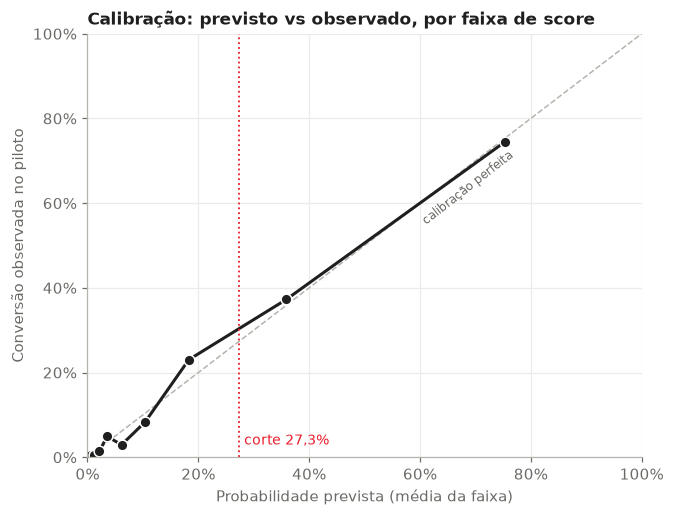

Seleção final (score médio > 27,3%): 366 contatos (18% da base) | conversão 59% | 69% dos compradores | lucro +1.278 MU (+627 por 1.000 clientes)


In [14]:
# @title Gráfico de calibração { display-mode: "form" }
score = oof["Regressão logística"].mean(axis=0)
df["score"] = score
calib = pd.DataFrame({"previsto": score, "observado": y}).groupby(pd.qcut(score, 10, labels=False)).mean()

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot([0, 1], [0, 1], color=GRAY, ls="--", lw=1)
ax.text(0.60, 0.55, "calibração perfeita", color=MUTED, fontsize=8, rotation=38)
ax.plot(calib["previsto"], calib["observado"], color=INK, lw=2, marker="o", ms=7, markeredgecolor="white")
ax.axvline(BREAKEVEN, color=ACCENT, ls=":", lw=1.2)
ax.text(BREAKEVEN + 0.01, 0.03, "corte 27,3%", color=ACCENT, fontsize=9)
ax.set_xlabel("Probabilidade prevista (média da faixa)")
ax.set_ylabel("Conversão observada no piloto")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0)); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.grid(axis="x")
ax.set_title("Calibração: previsto vs observado, por faixa de score")
plt.show()
final = avalia(score > BREAKEVEN)
print(f"Seleção final (score médio > 27,3%): {br(final['contatos'])} contatos ({pct(final['% da base'])} da base) | "
      f"conversão {pct(final['conversão'])} | {pct(final['% dos compradores captados'])} dos compradores | "
      f"lucro {mu(final['lucro'])} MU ({mu(final['lucro por 1.000 clientes'])} por 1.000 clientes)")

## 3.3 Curva de lucro: quantos clientes contatar?

Ordenando os clientes do maior para o menor score e somando o lucro, a curva **sobe** enquanto os contatados convertem acima de 27,3% e **desce** depois.

- O corte no break-even cai **no topo da curva**: 366 contatos (18% da base), **+627 por 1.000 clientes**.
- **O topo é plano:** contatar entre 16% e 29% da base fica a até 5% do lucro máximo. **A decisão é robusta** e não depende de acertar o corte exato. Se o negócio quiser mais volume, dá para ir até ~29% da base quase sem perder lucro.

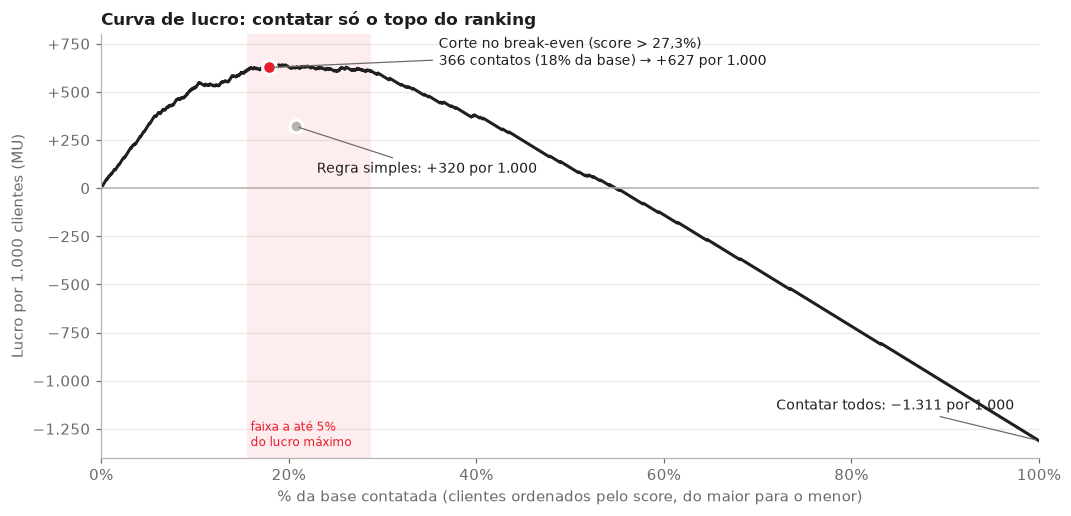

Faixa a até 5% do lucro máximo: de 16% a 29% da base


In [15]:
# @title Curva de lucro { display-mode: "form" }
ordem = np.argsort(-score)
lucro_acum = np.cumsum(y[ordem] * REVENUE - COST) / n * 1000
pct_base = np.arange(1, n + 1) / n
k_corte = (score > BREAKEVEN).sum()
plato = lucro_acum >= 0.95 * lucro_acum.max()
regra = avalia(df["prev_accepted"] > 0)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(pct_base[plato].min(), pct_base[plato].max(), color=ACCENT, alpha=0.08, lw=0)
ax.plot(np.r_[0, pct_base], np.r_[0, lucro_acum], color=INK, lw=2)
ax.axhline(0, color=GRAY, lw=1)
ax.scatter([k_corte / n], [lucro_acum[k_corte - 1]], s=80, color=ACCENT, zorder=3, edgecolor="white", lw=2)
ax.annotate(f"Corte no break-even (score > 27,3%)\n{k_corte} contatos ({pct(k_corte / n)} da base) → {mu(lucro_acum[k_corte - 1])} por 1.000",
            (k_corte / n, lucro_acum[k_corte - 1]), xytext=(0.36, 640), fontsize=9, color=INK,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.scatter([regra["% da base"]], [regra["lucro por 1.000 clientes"]], s=70, color=GRAY, zorder=3, edgecolor="white", lw=2)
ax.annotate(f"Regra simples: {mu(regra['lucro por 1.000 clientes'])} por 1.000",
            (regra["% da base"], regra["lucro por 1.000 clientes"]), xytext=(0.23, 100), va="center", fontsize=9, color=INK,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.annotate(f"Contatar todos: {mu(lucro_acum[-1])} por 1.000", (1, lucro_acum[-1]),
            xytext=(0.72, -1150), fontsize=9, color=INK, arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.text(pct_base[plato].min() + 0.004, -1340, "faixa a até 5%\ndo lucro máximo", fontsize=8, color=ACCENT)
ax.set_xlim(0, 1); ax.set_ylim(-1400, 800)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: mu(v)))
ax.set_xlabel("% da base contatada (clientes ordenados pelo score, do maior para o menor)")
ax.set_ylabel("Lucro por 1.000 clientes (MU)")
ax.set_title("Curva de lucro: contatar só o topo do ranking")
plt.show()
print(f"Faixa a até 5% do lucro máximo: de {pct(pct_base[plato].min())} a {pct(pct_base[plato].max())} da base")

## 3.4 Modelo vs regra simples: de onde vem o ganho?

A regra e o modelo concordam em 224 clientes (66% de conversão). O ganho vem de **duas trocas**:
- **+142 clientes que nunca aceitaram campanha, mas convertem 48%.** Compraram muito recentemente (16 dias, contra 49 na base) e são clientes antigos. É o **"dinheiro na mesa"** da regra.
- **−200 clientes que já aceitaram campanha, mas convertem só 14%.**

O ganho total é de **+625 MU**. O bootstrap (2.000 reamostragens) dá um intervalo de 95% de **+444 a +799 MU**, sempre positivo.

In [16]:
# @title Troca entre modelo e regra + bootstrap { display-mode: "form" }
sel_modelo = score > BREAKEVEN
sel_regra = (df["prev_accepted"] > 0).values
troca = pd.DataFrame({
    "Os dois selecionam": avalia(sel_modelo & sel_regra),
    "Só o modelo seleciona (nunca aceitaram campanha)": avalia(sel_modelo & ~sel_regra),
    "Só a regra seleciona (já aceitaram, score baixo)": avalia(~sel_modelo & sel_regra),
}).T
display(formata(troca[["contatos", "conversão", "lucro"]], {"contatos": br, "conversão": pct, "lucro": mu}))

rng = np.random.default_rng(42)
ganho_por_cliente = (sel_modelo.astype(int) - sel_regra.astype(int)) * (y * REVENUE - COST)
boot = [ganho_por_cliente[rng.integers(0, n, n)].sum() for _ in range(2000)]
print(f"Ganho do modelo sobre a regra: {mu(ganho_por_cliente.sum())} MU "
      f"(intervalo de 95%: {mu(np.percentile(boot, 2.5))} a {mu(np.percentile(boot, 97.5))})")
so_modelo = df[sel_modelo & ~sel_regra]
print(f"Só o modelo: recência mediana {so_modelo['Recency'].median():.0f} dias (base {df['Recency'].median():.0f}); "
      f"tempo de casa mediano {so_modelo['tenure_days'].median():.0f} dias (base {df['tenure_days'].median():.0f})")

,contatos,conversão,lucro
Os dois selecionam,224,66%,+956
Só o modelo seleciona (nunca aceitaram campanha),142,48%,+322
"Só a regra seleciona (já aceitaram, score baixo)",200,14%,−303


Ganho do modelo sobre a regra: +625 MU (intervalo de 95%: +444 a +799)
Só o modelo: recência mediana 16 dias (base 49); tempo de casa mediano 564 dias (base 351)


## 3.5 O que mais pesa no score?

Retiro um grupo de variáveis por vez, retreino e meço **quanto lucro se perde**. Não leio os coeficientes um a um porque as variáveis são correlacionadas (o gasto total é a soma dos gastos por categoria, por exemplo), e coeficientes isolados enganam. **Campanhas anteriores** e **recência** dominam; perfil e canal complementam. Valor e mix não acrescentam quando os outros grupos já estão no modelo, e valores perto de zero são ruído.

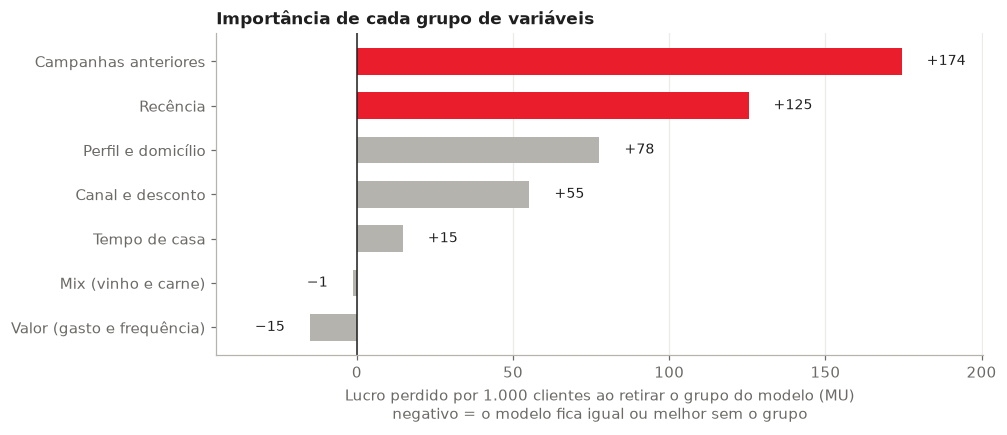

In [17]:
# @title Importância por grupo de variáveis { display-mode: "form" }
C_best = clone(logit).fit(X, y)[-1].C_[0]
simple_logit = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(C=C_best, max_iter=5000))
cv3 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)

def lucro_cv(cols):
    ps = np.zeros((3, n))
    for i, (tr, te) in enumerate(cv3.split(X, y)):
        ps[i // 5, te] = clone(simple_logit).fit(X.iloc[tr][cols], y[tr]).predict_proba(X.iloc[te][cols])[:, 1]
    return np.mean([avalia(p > BREAKEVEN)["lucro por 1.000 clientes"] for p in ps])

base_lucro = lucro_cv(model_features)
impacto = pd.Series({g: base_lucro - lucro_cv([f for f in model_features if f not in cols])
                     for g, cols in feature_groups.items()}).sort_values()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(impacto.index, impacto.values, color=[ACCENT if v >= impacto.max() * 0.5 else GRAY for v in impacto], height=0.6)
for i, v in enumerate(impacto.values):
    ax.text(v + (8 if v >= 0 else -8), i, mu(v), va="center", ha="left" if v >= 0 else "right", fontsize=9, color=INK)
ax.axvline(0, color=INK, lw=1)
ax.set_xlim(min(-45, impacto.min() - 30), impacto.max() * 1.15)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("Lucro perdido por 1.000 clientes ao retirar o grupo do modelo (MU)\nnegativo = o modelo fica igual ou melhor sem o grupo")
ax.set_title("Importância de cada grupo de variáveis")
plt.show()

## 3.6 E se o 11 for receita, e não margem?

O enunciado chama o 11 de **receita**. Se o produto tiver custo, o lucro por venda é menor e o break-even sobe: com margem de 50%, é preciso converter 54,5%. **A regra fixa passa a dar prejuízo; o modelo continua lucrando**, e basta mudar o corte para custo ÷ (receita × margem). É o argumento mais forte a favor de um score calibrado.

In [18]:
# @title Sensibilidade à margem do produto { display-mode: "form" }
sens = {}
for margem in [1.0, 0.75, 0.5]:
    rev = REVENUE * margem
    corte = COST / rev
    sens[f"margem {pct(margem)} (break-even {pct(corte, 1)})"] = {
        "Contatar todos": mu(avalia(np.ones(n), revenue=rev)["lucro por 1.000 clientes"]),
        "Regra simples": mu(avalia(sel_regra, revenue=rev)["lucro por 1.000 clientes"]),
        "Modelo (corte ajustado)": mu(avalia(score > corte, revenue=rev)["lucro por 1.000 clientes"]),
        "contatos do modelo (de 2.039 clientes)": br((score > corte).sum()),
    }
print("Lucro por 1.000 clientes (MU)")
pd.DataFrame(sens)

Lucro por 1.000 clientes (MU)


,"margem 100% (break-even 27,3%)","margem 75% (break-even 36,4%)","margem 50% (break-even 54,5%)"
Contatar todos,−1.311,−1.734,−2.156
Regra simples,+320,+84,−152
Modelo (corte ajustado),+627,+328,+105
contatos do modelo (de 2.039 clientes),366,297,185


## 3.7 Quem está na lista e como falar com cada perfil

- **Premium, 52% da lista:** 31% da persona é selecionada, e os selecionados convertem 63%. Oferta sem desconto, canal catálogo.
- **Econômico, 25% da lista:** só 11% da persona é selecionada, mas esses clientes convertem 61%. Mensagem com desconto, canal digital.
- **Intermediário, 23% da lista:** converte 48%. Gancho de vinho/harmonização.

In [19]:
# @title Distribuição da lista por persona { display-mode: "form" }
df["contatar"] = sel_modelo
lista = df.groupby("persona", observed=True).apply(lambda g: pd.Series({
    "clientes": br(len(g)), "selecionados": br(g["contatar"].sum()), "% da persona selecionada": pct(g["contatar"].mean()),
    "% da lista": pct(g["contatar"].sum() / sel_modelo.sum()),
    "conversão dos selecionados": pct(g.loc[g["contatar"], "Response"].mean()),
}))
lista

,clientes,selecionados,% da persona selecionada,% da lista,conversão dos selecionados
persona,,,,,
Econômico,827,93,11%,25%,61%
Intermediário,593,84,14%,23%,48%
Premium,619,189,31%,52%,63%


## 3.8 Projeção para a base completa

O enunciado fala em uma base de "centenas de milhares" de clientes. **Premissas:** o piloto é aleatório e representa a base; custo e receita se mantêm. **Para cada 100 mil clientes**, o modelo faz **82% menos contatos** e mantém **69% das vendas**, trocando −131 mil MU por **+63 mil MU**.

In [20]:
# @title Projeção para 100 mil clientes { display-mode: "form" }
BASE = 100_000
proj = {}
for nome, sel in [("Contatar todos", np.ones(n, bool)), ("Regra simples", sel_regra), ("Modelo", sel_modelo)]:
    a = avalia(sel)
    proj[nome] = {"contatos": br(a["% da base"] * BASE, 0), "compras esperadas": br(a["% da base"] * BASE * a["conversão"]),
                  "custo (MU)": br(a["% da base"] * BASE * COST), "receita (MU)": br(a["% da base"] * BASE * a["conversão"] * REVENUE),
                  "lucro (MU)": mu(a["lucro por 1.000 clientes"] * BASE / 1000)}
pd.DataFrame(proj).T

,contatos,compras esperadas,custo (MU),receita (MU),lucro (MU)
Contatar todos,100.000,15.351,300.000,168.857,−131.143
Regra simples,20.795,8.583,62.384,94.409,+32.026
Modelo,17.950,10.593,53.850,116.528,+62.678


## 3.9 Recomendação

1. **Deduplicar a base de contatos** antes do disparo e no reporte do resultado.
2. **Calcular o score de toda a base no dia do disparo**, com recência e demais variáveis atualizadas, e contatar quem tiver **score > 27,3%** (~18% da base). Excluir quem já comprou o produto no piloto.
3. **Adaptar a mensagem ao perfil** do cliente (3.7).
4. **Recalcular o corte se a economia mudar:** corte = custo ÷ (receita × margem).
5. **Expectativa:** sair de **−1.311** para cerca de **+627 MU por 1.000 clientes**.

A célula abaixo salva a lista de score e decisão de cada cliente do piloto. Ela é **ilustrativa**, porque esses clientes já foram contatados: a entrega real é o score aplicado ao **restante da base**.

In [21]:
# @title Exportar lista com score e decisão { display-mode: "form" }
Path("outputs").mkdir(exist_ok=True)
(df.assign(decisao=np.where(df["contatar"], "contatar", "não contatar"))
   [["ID", "score", "decisao", "persona", "prev_accepted", "Recency", "Response"]]
   .sort_values("score", ascending=False)
   .to_csv("outputs/lista_scores_piloto.csv", index=False))
print("Lista ilustrativa salva em outputs/lista_scores_piloto.csv")

Lista ilustrativa salva em outputs/lista_scores_piloto.csv


---
# 4. Limitações e próximos passos

## 4.1 Como testar na próxima campanha

O piloto não teve grupo de controle. Por isso o modelo mede **propensão** (quem compra quando é contatado), e não **efeito causal** (quem compra *por causa* do contato). Proposta de teste com três braços:

| Braço | Quem | Para quê |
|---|---|---|
| **A. Tratamento** | Selecionados pelo modelo, contatados | Medir o resultado da estratégia |
| **B. Controle** | Selecionados pelo modelo, **não** contatados | Medir quanto da compra é causada pela campanha (*uplift* = A − B) |
| **C. Exploração** | Pequena amostra aleatória **abaixo** do corte, contatada | Continuar gerando dados onde o modelo diz "não". Sem isso, o modelo nunca descobre se errou |

O braço C é o mesmo problema de um sistema antifraude: **transação bloqueada nunca vira dado**, e o modelo deixa de aprender sobre ela. A solução também é a mesma: liberar uma amostra controlada (*reject inference*, desenho *champion/challenger*).

In [22]:
# @title Tamanho dos braços e custo da exploração { display-mode: "form" }
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

conv_sel = y[sel_modelo].mean()
n_braco = NormalIndPower().solve_power(proportion_effectsize(conv_sel, conv_sel - 0.10), alpha=0.05, power=0.8)
conv_abaixo = y[~sel_modelo].mean()
print(f"Conversão esperada dos selecionados: {pct(conv_sel)}")
print(f"Clientes por braço para detectar 10 p.p. de efeito (α = 5%, poder = 80%): {np.ceil(n_braco):.0f}")
print(f"Conversão esperada abaixo do corte: {pct(conv_abaixo, 1)} → cada contato exploratório custa em média {br(COST - conv_abaixo * REVENUE, 2)} MU")

Conversão esperada dos selecionados: 59%
Clientes por braço para detectar 10 p.p. de efeito (α = 5%, poder = 80%): 389
Conversão esperada abaixo do corte: 5,8% → cada contato exploratório custa em média 2,36 MU


Cerca de **390 clientes por braço** (A e B) bastam para detectar 10 pontos percentuais de efeito. O braço C tem custo (cada contato abaixo do corte perde, em média, 2,36 MU), então deve ser pequeno, por exemplo 2% a 5% dos não selecionados, e tratado como **custo de aprendizado**.

## 4.2 O que acompanhar
- **Calibração:** conversão por faixa de score contra a prevista.
- **Lucro realizado contra o projetado**, por 1.000 clientes.
- **Uplift:** conversão do braço A menos a do braço B.
- **Mudança no perfil da base** em relação aos dados do treino.
- **Proteção:** descadastros e reclamações entre os contatados.

## 4.3 Limitações e premissas
- **Propensão ≠ uplift:** sem controle no piloto, parte dos compradores poderia comprar de qualquer jeito.
- **Produto novo:** assumo que quem respondeu ao piloto responde igual na próxima campanha.
- **11 é receita:** se houver custo do produto, o corte sobe (3.6).
- **Amostra pequena:** 313 compradores, por isso reporto faixas e não um único número.
- **Recência:** precisa ser recalculada no dia do disparo.
- **Qualidade dos dados:** 9% de registros duplicados; vale entender a origem antes de escalar.
- **Custo de contato fixo:** se os canais tiverem custos diferentes, o corte pode ser definido por canal.

---
# Apêndice

## A.1 Glossário

| Termo | Significado |
|---|---|
| **MU** | *Monetary Units*: unidade monetária genérica do enunciado. |
| **Conversão** | % dos clientes contatados que compraram (`Response = 1`). |
| **Break-even** | Conversão mínima para a campanha empatar: 3 ÷ 11 = 27,3%. |
| **Mediana** | Valor do meio quando ordenamos os dados; não é puxada por extremos. |
| **Imputar** | Preencher um valor faltante ou inválido com uma estimativa razoável. |
| **Quintil** | Divisão dos clientes em 5 grupos do mesmo tamanho (Q1 = 20% menores, Q5 = 20% maiores). |
| **RFM** | Recência, Frequência e valor Monetário: forma clássica de descrever clientes em marketing. |
| **Padronizar** | Colocar variáveis na mesma escala (média 0, desvio 1). |
| **K-means** | Algoritmo que agrupa clientes parecidos; o número de grupos é escolhido pelo analista. |
| **Silhouette** | Nota de −1 a 1 de quão separados estão os grupos; quanto maior, mais distintos. |
| **Score / propensão** | Probabilidade estimada de o cliente comprar se for contatado. |
| **Validação cruzada / fold** | Treina em parte da base e mede em outra que o modelo não viu; repete para todas as partes. |
| **Vazamento** | Quando informação da resposta "vaza" para o treino e o modelo parece melhor do que é. |
| **AUC** | Chance de o modelo dar nota maior a um comprador do que a um não comprador sorteados ao acaso. |
| **Calibração** | Quanto a probabilidade prevista bate com a frequência observada. |
| **Bootstrap** | Reamostrar a base muitas vezes para medir a incerteza de um resultado. |
| **Uplift** | Efeito causal da campanha: conversão com contato menos conversão sem contato. |

## A.2 Dicionário de dados

| Grupo | Coluna | Significado |
|---|---|---|
| Identificação | `ID` | Identificador do registro do cliente |
| Perfil | `Year_Birth` | Ano de nascimento |
| Perfil | `Education` | Escolaridade: `Basic`, `2n Cycle` (mestrado no padrão europeu), `Graduation`, `Master`, `PhD` |
| Perfil | `Marital_Status` | Estado civil |
| Perfil | `Income` | Renda familiar anual |
| Perfil | `Kidhome` / `Teenhome` | Nº de crianças pequenas / adolescentes no domicílio |
| Relacionamento | `Dt_Customer` | Data de cadastro do cliente |
| Relacionamento | `Recency` | Dias desde a última compra |
| Relacionamento | `Complain` | Reclamou nos últimos 2 anos (1 = sim) |
| Consumo (2 anos) | `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds` | Valor gasto com vinhos, frutas, carnes, peixes, doces e produtos "gold" (linha premium) |
| Canal | `NumWebPurchases` / `NumCatalogPurchases` / `NumStorePurchases` | Nº de compras pelo site / por catálogo / em loja física |
| Canal | `NumDealsPurchases` | Nº de compras com desconto (em qualquer canal) |
| Canal | `NumWebVisitsMonth` | Nº de visitas ao site no último mês |
| Campanhas | `AcceptedCmp1` … `AcceptedCmp5` | Aceitou a oferta da 1ª … 5ª campanha anterior (1 = sim) |
| Economia | `Z_CostContact` / `Z_Revenue` | Custo por contato (3) / receita por conversão (11), constantes (seção 0.1) |
| **Alvo** | `Response` | **Aceitou a oferta da campanha piloto (1 = sim).** É o que queremos prever. |

## A.3 Detalhes do tratamento

**Por que imputar a renda em vez de remover os clientes?**
1. A próxima campanha também terá clientes sem renda; remover do treino só esconde o problema.
2. Remover descartaria as outras ~25 informações desses clientes, que são válidas.
3. São ~1% dos clientes, e a renda nem é a variável mais forte.
4. A mediana não é puxada por extremos, ao contrário da média.
5. A flag `income_imputed` preserva a informação de que a renda era desconhecida.

O `666.666` é tratado como faltante: é ~4× a segunda maior renda (162.397) e tem cara de valor digitado.

**Por que `Alone`, `Absurd` e `YOLO` viram `Single`?** `Alone` é, na prática, solteiro; `Absurd` e `YOLO` são lixo de cadastro. O que entra nas análises é *mora com parceiro(a)*, e sem evidência de parceiro o mais neutro é "não". São 7 registros (0,3%), então qualquer escolha razoável não muda o resultado.

## A.4 Por que vinho e carne no mix?

1. **Tamanho:** vinho (50%) e carne (28%) somam 78% de todo o gasto.
2. **Variação:** são as categorias em que os clientes mais diferem.
3. **Redundância:** como as participações somam 100%, peixe, frutas e doces andam juntos e, somados, são o espelho do vinho (correlação de −0,78).
4. **A carne é um eixo separado** e tem sinal: os 25% com mais carne na cesta convertem 22%, contra ~13% nos demais.

In [23]:
# @title Participação, variação e sinal de cada categoria { display-mode: "form" }
cat_names = {"MntWines": "Vinho", "MntMeatProducts": "Carne", "MntGoldProds": "Gold",
             "MntFishProducts": "Peixe", "MntSweetProducts": "Doces", "MntFruits": "Frutas"}
shares = df[list(cat_names)].div(df["total_spend"], axis=0).rename(columns=cat_names)
top_q = lambda c: df.loc[shares[c] >= shares[c].quantile(0.75), "Response"].mean()
pd.DataFrame({
    "% do gasto total da base": [pct(v) for v in df[list(cat_names)].sum().values / df["total_spend"].sum()],
    "desvio da participação entre clientes": [br(v, 2) for v in shares.std().values],
    "correlação com a participação do vinho": [br(v, 2) for v in shares.corr()["Vinho"].values],
    "conversão no quartil com mais participação": [pct(top_q(c)) for c in shares],
}, index=shares.columns)

,% do gasto total da base,desvio da participação entre clientes,correlação com a participação do vinho,conversão no quartil com mais participação
Vinho,50%,"0,23","1,00",13%
Carne,28%,"0,13","-0,46",22%
Gold,7%,"0,11","-0,52",15%
Peixe,6%,"0,08","-0,60",11%
Doces,4%,"0,06","-0,55",13%
Frutas,4%,"0,06","-0,58",12%


## A.5 Robustez da segmentação

**Teste 1: incluir o % do gasto em carne.** Se os perfis mudassem muito, a segmentação seria frágil.

In [24]:
# @title Teste: personas com % de carne { display-mode: "form" }
from sklearn.metrics import adjusted_rand_score

def personas_com(features, k=3):
    Xf = df[features].copy()
    Xf["total_spend"] = np.log1p(Xf["total_spend"])
    Zf = StandardScaler().fit_transform(Xf)
    lab = KMeans(k, n_init=20, random_state=42).fit_predict(Zf)
    ordem_ = pd.Series(df["total_spend"].values).groupby(lab).median().sort_values().index
    return pd.Series(lab).map(dict(zip(ordem_, ["Econômico", "Intermediário", "Premium"]))).values, silhouette_score(Zf, lab)

persona_carne, sil_carne = personas_com(seg_features + ["meat_share"])
print(f"Clientes que continuam na mesma persona: {pct((df['persona'].astype(str).values == persona_carne).mean())}")
print(f"Concordância (Adjusted Rand Index, 1 = idêntico): {br(adjusted_rand_score(df['persona'].astype(str), persona_carne), 2)}")
print(f"Silhouette: sem carne {br(scores[3], 2)} | com carne {br(sil_carne, 2)}")
pd.crosstab(df["persona"], persona_carne, rownames=["sem carne"], colnames=["com carne"])

Clientes que continuam na mesma persona: 95%
Concordância (Adjusted Rand Index, 1 = idêntico): 0,86
Silhouette: sem carne 0,28 | com carne 0,27


com carne,Econômico,Intermediário,Premium
sem carne,,,
Econômico,825,2,0
Intermediário,32,547,14
Premium,0,63,556


**Resultado:** 95% dos clientes ficam na mesma persona, e a separação piora levemente. Mantenho a versão sem carne, que é mais simples e dá o mesmo resultado.

**Teste 2: as personas são só faixas de gasto?**

In [25]:
# @title Teste: personas vs faixas de gasto { display-mode: "form" }
tamanhos = df["persona"].value_counts().reindex(["Econômico", "Intermediário", "Premium"]).cumsum() / len(df)
faixa_gasto = pd.cut(df["total_spend"].rank(pct=True, method="first"), [0, *tamanhos.values],
                     labels=["Econômico", "Intermediário", "Premium"])
print(f"Clientes no mesmo grupo que um corte simples por gasto (grupos do mesmo tamanho): "
      f"{pct((faixa_gasto.astype(str) == df['persona'].astype(str)).mean())}")

Clientes no mesmo grupo que um corte simples por gasto (grupos do mesmo tamanho): 82%


**Resultado:** em boa parte, sim (82% de coincidência). O agrupamento acrescenta domicílio, canal e desconto, que orientam a mensagem, mas a decisão de quem contatar vem do modelo.

## A.6 Robustez da decisão sobre duplicatas

Nos 19 grupos de cópias com respostas diferentes, o cliente foi contado como comprador. A alternativa é excluir esses grupos e rodar o modelo de novo.

In [26]:
# @title Teste: alternativa para as cópias conflitantes { display-mode: "form" }
mask = ~df["resposta_conflitante"].values
p_alt = np.zeros((3, mask.sum()))
for i, (tr, te) in enumerate(RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42).split(X[mask], y[mask])):
    p_alt[i // 5, te] = clone(logit).fit(X[mask].iloc[tr], y[mask][tr]).predict_proba(X[mask].iloc[te])[:, 1]
alt = pd.DataFrame({
    "Comprador se alguma cópia comprou (escolhido)": linhas["Regressão logística"],
    "Excluindo os 19 grupos conflitantes": pd.DataFrame([avalia(p > BREAKEVEN, y=y[mask]) for p in p_alt]).mean(),
}).T
formata(alt[["contatos", "conversão", "lucro por 1.000 clientes"]], {"contatos": br, "conversão": pct, "lucro por 1.000 clientes": mu})

,contatos,conversão,lucro por 1.000 clientes
Comprador se alguma cópia comprou (escolhido),370,58%,+623
Excluindo os 19 grupos conflitantes,343,58%,+573


**Resultado:** a qualidade da seleção é a mesma (58% de conversão). O lucro por 1.000 fica um pouco menor só porque esses 19 clientes, que compraram, saem da base. A escolha não altera a recomendação.